<a href="https://colab.research.google.com/github/HimathDissa/Unified-Logistics-Solution-CP60056E/blob/main/NorthStar_SQL_in_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
if (!require("sqldf"))   install.packages("sqldf",   quiet = TRUE)
if (!require("dplyr"))   install.packages("dplyr",   quiet = TRUE)
if (!require("ggplot2")) install.packages("ggplot2", quiet = TRUE)
if (!require("scales"))  install.packages("scales",  quiet = TRUE)

library(sqldf)
library(dplyr)
library(ggplot2)
library(scales)

Loading required package: sqldf

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sqldf’”
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: scales

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [ ]:
#Load all datasets

customers  <- read.csv("/content/customers.csv")
orders     <- read.csv("/content/orders.csv")
deliveries <- read.csv("/content/deliveries.csv")
drivers    <- read.csv("/content/drivers.csv")
vehicles   <- read.csv("/content/vehicles.csv")
hubs       <- read.csv("/content/hubs.csv")
incidents  <- read.csv("/content/incidents.csv")
complaints <- read.csv("/content/complaints.csv")

cat("All datasets loaded!\n")

All datasets loaded!


In [ ]:
# Data Cleaning

standardise_zone <- function(z) toupper(trimws(z))

orders$pickup_zone   <- standardise_zone(orders$pickup_zone)
orders$dropoff_zone  <- standardise_zone(orders$dropoff_zone)
customers$home_zone  <- standardise_zone(customers$home_zone)
drivers$base_zone    <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone <- standardise_zone(vehicles$assigned_zone)
hubs$zone            <- standardise_zone(hubs$zone)

# Standardise service_type and delivery_status capitalisation
orders$service_type      <- trimws(orders$service_type)
deliveries$delivery_status <- trimws(deliveries$delivery_status)
complaints$complaint_type  <- trimws(complaints$complaint_type)
incidents$incident_type    <- trimws(incidents$incident_type)

cat("Zone and category standardisation complete.\n\n")

Zone and category standardisation complete.



=== QUERY 1: Delivery Performance by Zone ===
       zone total_deliveries failed delayed on_time failure_rate_pct avg_rating
1       CTR               64     11      24      29             54.7       3.43
2   CENTRAL              110     22      27      61             44.5       3.62
3   AIRPORT              113     12      31      70             38.1       3.98
4 RIVERSIDE              119     18      25      76             36.1       3.86
5      EAST              156     19      31     106             32.1       3.91
6     NORTH              135     22      21      92             31.9       3.90
7      WEST              114     14      21      79             30.7       3.90
8     SOUTH              139     14      22     103             25.9       4.05



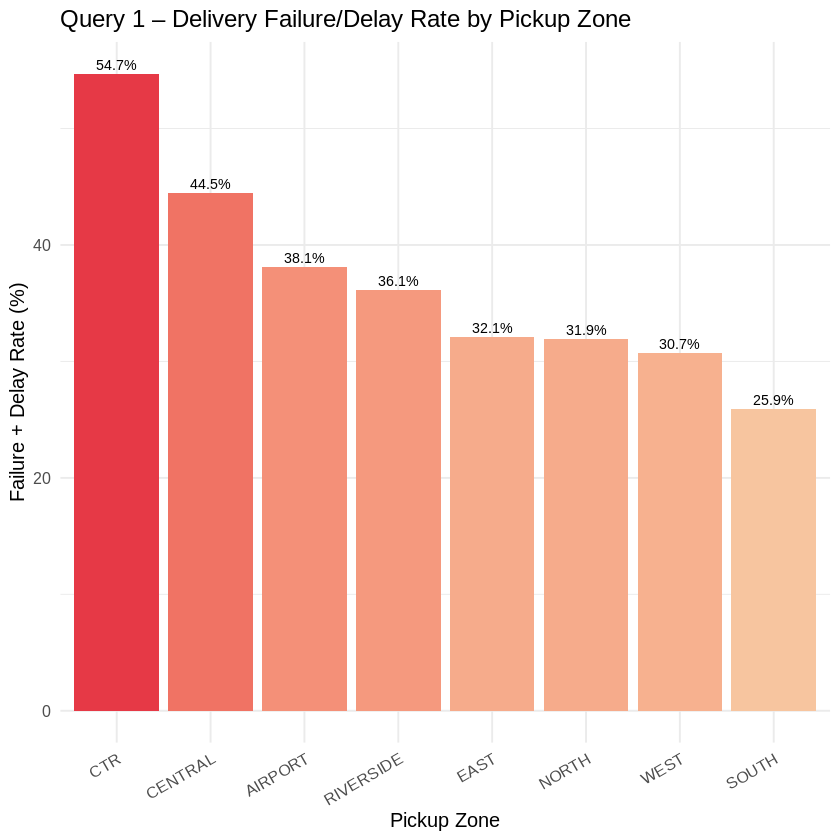

In [ ]:
# QUERY 1 – Delivery Performance by Zone

q1 <- sqldf("
  SELECT
    o.pickup_zone                                          AS zone,
    COUNT(d.delivery_id)                                   AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END) AS on_time,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 1)                           AS failure_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2)         AS avg_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

cat("=== QUERY 1: Delivery Performance by Zone ===\n")
print(q1)
cat("\n")

# Visualisation for Q1
ggplot(q1, aes(x = reorder(zone, -failure_rate_pct), y = failure_rate_pct, fill = failure_rate_pct)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = paste0(failure_rate_pct, "%")), vjust = -0.4, size = 3) +
  scale_fill_gradient(low = "#f7c59f", high = "#e63946") +
  labs(title = "Query 1 – Delivery Failure/Delay Rate by Pickup Zone",
       x = "Pickup Zone", y = "Failure + Delay Rate (%)") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

=== QUERY 2: Top 20 Drivers by Average Route Overrides ===
   driver_id base_zone employment_type total_deliveries avg_overrides failed
1       D127   CENTRAL        FullTime                6          2.83      0
2       D062     SOUTH        FullTime                3          2.00      1
3       D069     NORTH        PartTime                7          2.00      1
4       D085     NORTH        PartTime                4          2.00      0
5       D105 RIVERSIDE        Contract                7          2.00      1
6       D124     NORTH        FullTime                4          2.00      0
7       D130      WEST        FullTime                8          2.00      1
8       D139     SOUTH        FullTime                5          2.00      0
9       D028     NORTH        FullTime                7          1.86      1
10      D027   AIRPORT        PartTime                6          1.83      1
11      D143   CENTRAL        FullTime                5          1.80      2
12      D003   AI

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


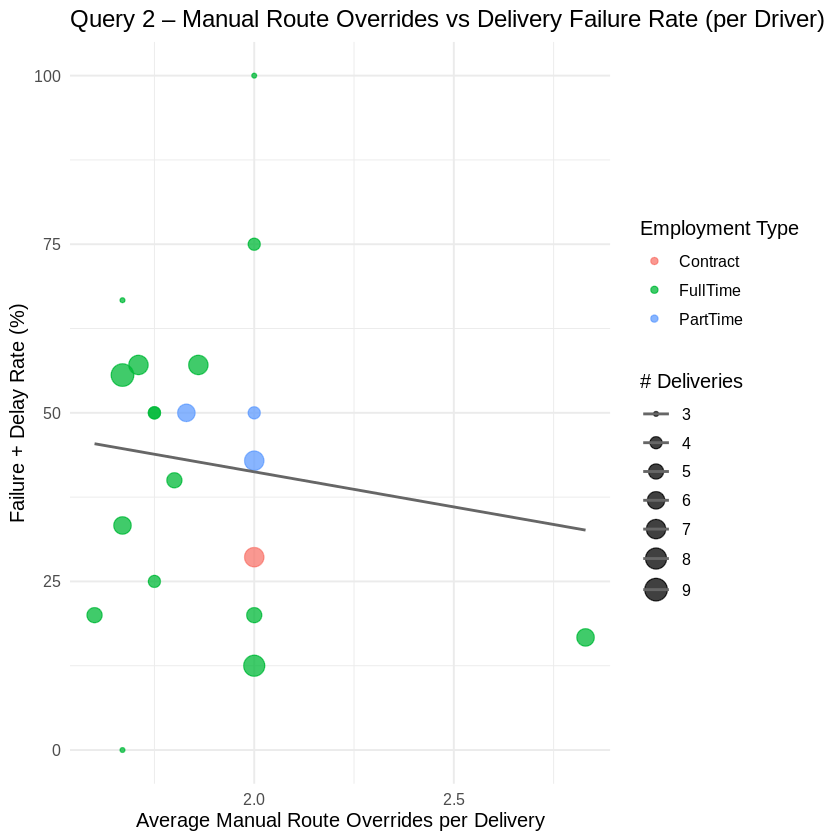

In [ ]:
# QUERY 2 – Driver Performance vs Manual Route Overrides

q2 <- sqldf("
  SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    COUNT(d.delivery_id)                                        AS total_deliveries,
    ROUND(AVG(d.manual_route_override_count), 2)                AS avg_overrides,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
      100.0 * SUM(CASE WHEN d.delivery_status IN ('Failed','Delayed') THEN 1 ELSE 0 END)
      / COUNT(d.delivery_id), 1)                                AS failure_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2)              AS avg_rating,
    ROUND(AVG(dr.driver_rating), 2)                             AS driver_platform_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id, dr.base_zone, dr.employment_type
  HAVING total_deliveries >= 3
  ORDER BY avg_overrides DESC
  LIMIT 20
")

cat("=== QUERY 2: Top 20 Drivers by Average Route Overrides ===\n")
print(q2)
cat("\n")

# Scatter: overrides vs failure rate
ggplot(q2, aes(x = avg_overrides, y = failure_rate_pct, colour = employment_type, size = total_deliveries)) +
  geom_point(alpha = 0.75) +
  geom_smooth(method = "lm", se = FALSE, colour = "grey40", linewidth = 0.8) +
  labs(title = "Query 2 – Manual Route Overrides vs Delivery Failure Rate (per Driver)",
       x = "Average Manual Route Overrides per Delivery",
       y = "Failure + Delay Rate (%)",
       colour = "Employment Type", size = "# Deliveries") +
  theme_minimal(base_size = 12)

=== QUERY 3: Complaints by Service Type, Type & Severity ===
   service_type    complaint_type severity total_complaints open_complaints
1        Retail             Delay   Medium               20               2
2     Passenger             Delay   Medium               14               4
3        Retail      MissedPickup   Medium               14               2
4        Parcel   DriverBehaviour   Medium               12               0
5      Business             Delay   Medium               10               2
6     Passenger          AppIssue   Medium                9               1
7        Parcel             Delay   Medium                8               1
8        Retail          AppIssue   Medium                8               0
9        Retail             Delay      Low                8               2
10      Medical      MissedPickup   Medium                7               1
11       Parcel             Delay      Low                7               0
12       Parcel   DriverBeh

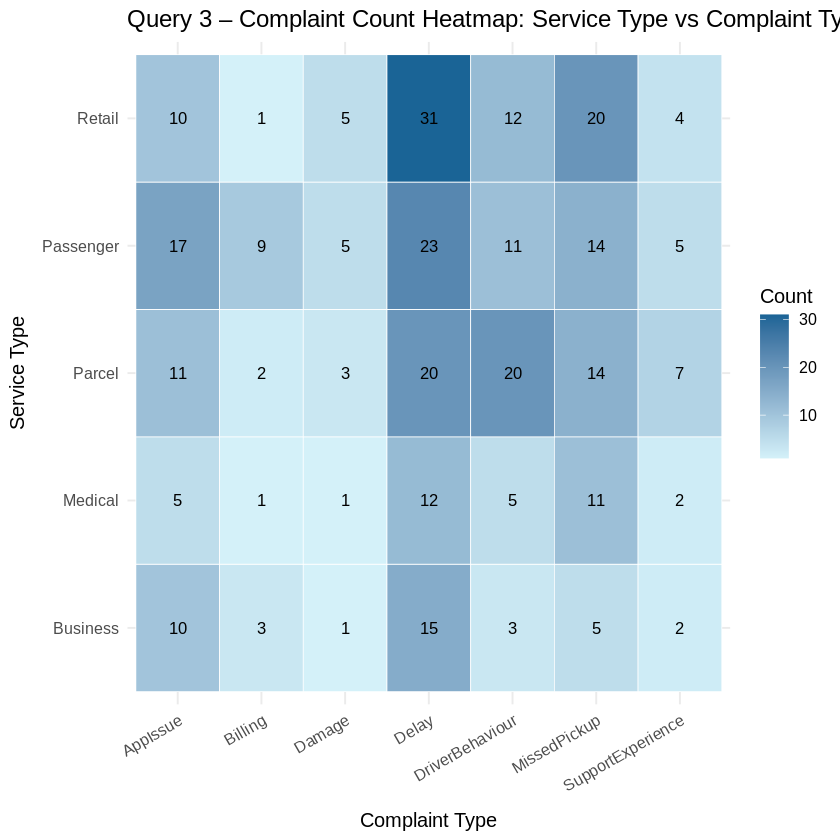

In [ ]:
# QUERY 3 – Customer Complaint Analysis by Service Type and Severity

q3 <- sqldf("
  SELECT
    o.service_type,
    c.complaint_type,
    c.severity,
    COUNT(c.complaint_id)                                          AS total_complaints,
    SUM(CASE WHEN c.status = 'Open'      THEN 1 ELSE 0 END)        AS open_complaints,
    SUM(CASE WHEN c.status = 'Escalated' THEN 1 ELSE 0 END)        AS escalated_complaints,
    ROUND(AVG(c.resolution_days), 1)                               AS avg_resolution_days,
    ROUND(AVG(COALESCE(c.compensation_amount, 0)), 2)              AS avg_compensation
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.service_type, c.complaint_type, c.severity
  ORDER BY total_complaints DESC
")

cat("=== QUERY 3: Complaints by Service Type, Type & Severity ===\n")
print(q3)
cat("\n")

# Aggregated heatmap view: service type vs complaint type
q3_heat <- sqldf("
  SELECT
    o.service_type,
    c.complaint_type,
    COUNT(c.complaint_id) AS total
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.service_type, c.complaint_type
")

ggplot(q3_heat, aes(x = complaint_type, y = service_type, fill = total)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = total), size = 3.5) +
  scale_fill_gradient(low = "#d4f1f9", high = "#1a6496") +
  labs(title = "Query 3 – Complaint Count Heatmap: Service Type vs Complaint Type",
       x = "Complaint Type", y = "Service Type", fill = "Count") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

=== QUERY 4: Vehicle Health & Incident Summary (Top 20) ===
   vehicle_id vehicle_type assigned_zone maintenance_status avg_battery_health
1        V047           EV           CTR          Scheduled               93.7
2        V108       Diesel       AIRPORT           InRepair               54.6
3        V030     CargoVan         NORTH             Active               78.0
4        V046           EV         NORTH             Active               95.8
5        V097           EV           CTR             Active               92.1
6        V005     CargoVan          WEST             Active               58.6
7        V009     CargoVan         SOUTH             Active               68.8
8        V035     CargoVan          EAST             Active               83.6
9        V042           EV          EAST           InRepair               80.5
10       V076       Diesel       CENTRAL           InRepair               65.8
11       V088       Diesel         NORTH           InRepair            

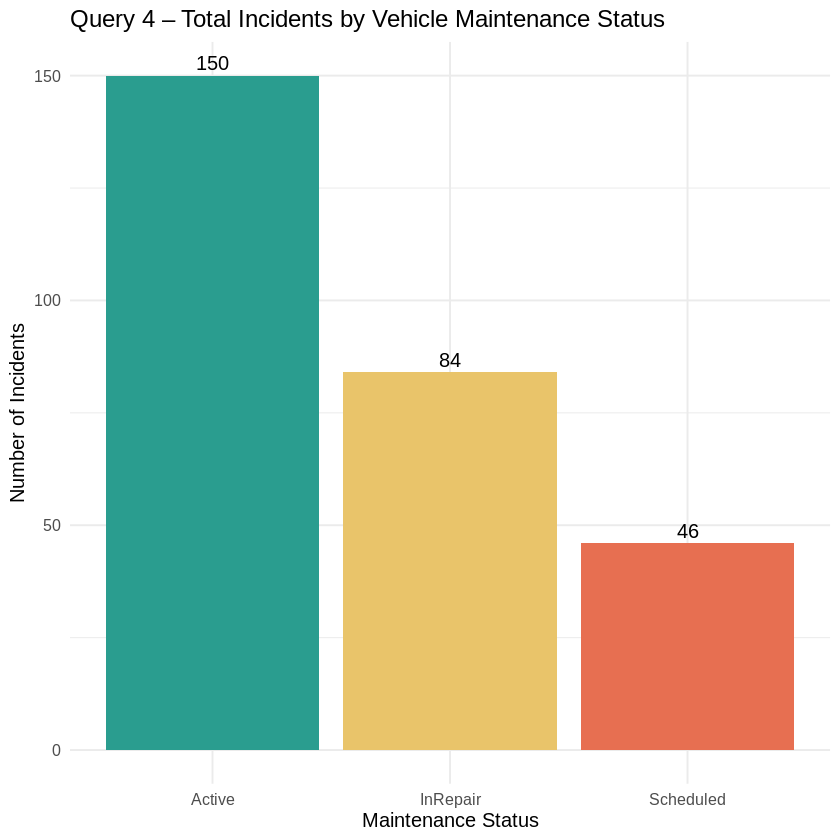

In [ ]:
# QUERY 4 – Vehicle Health and Incident Correlation


q4 <- sqldf("
  SELECT
    v.vehicle_id,
    v.vehicle_type,
    v.assigned_zone,
    v.maintenance_status,
    ROUND(AVG(v.battery_health_pct), 1)                       AS avg_battery_health,
    COUNT(i.incident_id)                                       AS total_incidents,
    SUM(CASE WHEN i.severity = 'High'     THEN 1 ELSE 0 END)  AS high_sev_incidents,
    SUM(CASE WHEN i.severity = 'Critical' THEN 1 ELSE 0 END)  AS critical_incidents,
    SUM(CASE WHEN i.incident_type = 'BatteryAlert' THEN 1 ELSE 0 END) AS battery_alerts,
    SUM(CASE WHEN i.incident_type = 'VehicleFault' THEN 1 ELSE 0 END) AS vehicle_faults,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                      AS avg_charge_cost
  FROM vehicles v
  LEFT JOIN deliveries d  ON v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents  i  ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, v.vehicle_type, v.assigned_zone, v.maintenance_status
  ORDER BY total_incidents DESC
  LIMIT 20
")

cat("=== QUERY 4: Vehicle Health & Incident Summary (Top 20) ===\n")
print(q4)
cat("\n")

# Bar: incidents by maintenance status
q4_maint <- sqldf("
  SELECT
    v.maintenance_status,
    COUNT(i.incident_id)                                      AS total_incidents,
    SUM(CASE WHEN i.severity IN ('High','Critical') THEN 1 ELSE 0 END) AS serious_incidents,
    ROUND(AVG(v.battery_health_pct), 1)                       AS avg_battery_pct
  FROM vehicles v
  LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  LEFT JOIN incidents  i ON d.delivery_id = i.delivery_id
  GROUP BY v.maintenance_status
")

ggplot(q4_maint, aes(x = maintenance_status, y = total_incidents, fill = maintenance_status)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = total_incidents), vjust = -0.4) +
  scale_fill_manual(values = c("Active" = "#2a9d8f", "InRepair" = "#e9c46a", "Scheduled" = "#e76f51")) +
  labs(title = "Query 4 – Total Incidents by Vehicle Maintenance Status",
       x = "Maintenance Status", y = "Number of Incidents") +
  theme_minimal(base_size = 12)

=== QUERY 5: Repeat Complainants (2+ complaints) ===
   customer_id home_zone customer_type loyalty_score total_complaints
1        C0368     NORTH      Consumer          49.5                4
2        C0110      EAST      Consumer            NA                3
3        C0142     SOUTH      Consumer          47.0                3
4        C0242      EAST      Consumer          83.8                3
5        C0282 RIVERSIDE      Consumer          71.4                3
6        C0372      WEST      Consumer          26.2                3
7        C0626     SOUTH      Consumer          61.6                3
8        C0172     NORTH      Consumer          75.4                3
9        C0191     NORTH      Consumer          58.9                3
10       C0421   CENTRAL      Consumer          59.0                3
11       C0545     SOUTH      Consumer          66.9                3
12       C0573   AIRPORT           SME          57.3                3
13       C0054      WEST      Consume

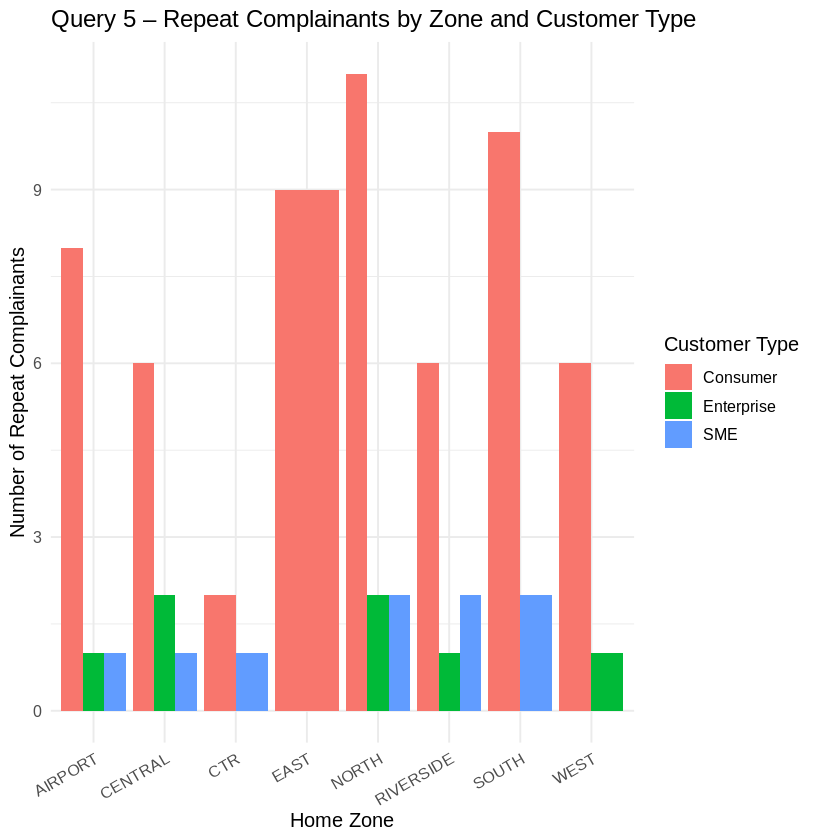

In [ ]:
# QUERY 5 – Repeat Complainants: High-Risk Customer Identification

q5 <- sqldf("
  SELECT
    c.customer_id,
    cu.home_zone,
    cu.customer_type,
    cu.loyalty_score,
    COUNT(c.complaint_id)                                          AS total_complaints,
    SUM(CASE WHEN c.severity = 'High' THEN 1 ELSE 0 END)           AS high_sev_complaints,
    SUM(CASE WHEN c.status = 'Open' OR c.status = 'Escalated'
             THEN 1 ELSE 0 END)                                    AS unresolved_complaints,
    ROUND(AVG(c.resolution_days), 1)                               AS avg_resolution_days,
    ROUND(SUM(COALESCE(c.compensation_amount, 0)), 2)              AS total_compensation_paid
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.customer_id, cu.home_zone, cu.customer_type, cu.loyalty_score
  HAVING total_complaints >= 2
  ORDER BY total_complaints DESC, unresolved_complaints DESC
")

cat("=== QUERY 5: Repeat Complainants (2+ complaints) ===\n")
print(q5)
cat("\n")

# Summary: repeat complaint distribution by zone and customer type
q5_zone <- sqldf("
  SELECT
    cu.home_zone,
    cu.customer_type,
    COUNT(DISTINCT c.customer_id)              AS repeat_complainants,
    ROUND(AVG(c_counts.cnt), 1)                AS avg_complaints_per_customer,
    ROUND(SUM(COALESCE(c.compensation_amount,0)), 2) AS total_compensation
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  JOIN (
    SELECT customer_id, COUNT(*) AS cnt
    FROM complaints
    GROUP BY customer_id
    HAVING cnt >= 2
  ) c_counts ON c.customer_id = c_counts.customer_id
  GROUP BY cu.home_zone, cu.customer_type
  ORDER BY repeat_complainants DESC
")

ggplot(q5_zone, aes(x = home_zone, y = repeat_complainants, fill = customer_type)) +
  geom_col(position = "dodge") +
  labs(title = "Query 5 – Repeat Complainants by Zone and Customer Type",
       x = "Home Zone", y = "Number of Repeat Complainants", fill = "Customer Type") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

cat("=== All SQL queries complete. ===\n")